# Model Comparison

Loads results saved by `python -m evaluation.run_eval` and displays them.

Run the eval first:
```bash
python -m evaluation.run_eval --qa 50 --rg 20
```

In [1]:
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')
comparison = pd.read_csv(RESULTS / 'comparison.csv', index_col=0)
comparison

,bleu,rougeL,token_f1,recall_at_3
no_rag,0.0673,0.2619,0.2464,NaN
clip,0.1217,0.3856,0.3869,1.0
colpali,0.1391,0.3778,0.3786,1.0
report_gen_medgemma,0.0294,0.2045,0.2405,NaN


## Bar chart

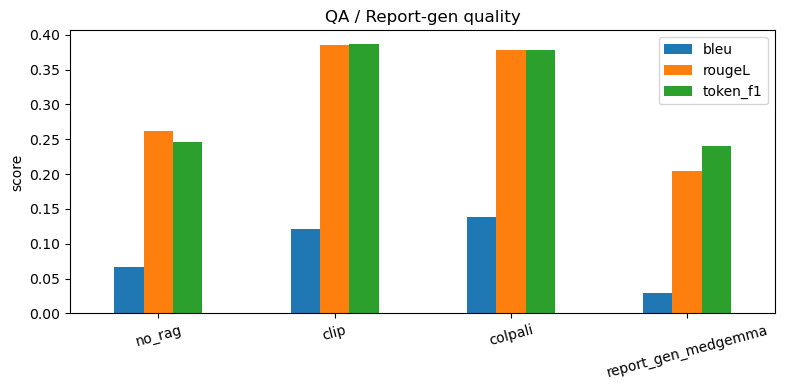

In [2]:
import matplotlib.pyplot as plt

ax = comparison[['bleu', 'rougeL', 'token_f1']].plot(kind='bar', figsize=(8, 4))
ax.set_ylabel('score')
ax.set_title('QA / Report-gen quality')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

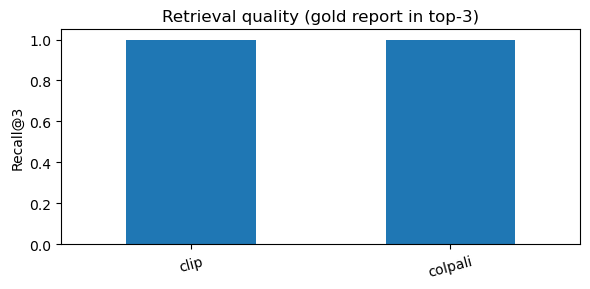

In [3]:
if 'recall_at_3' in comparison.columns:
    comparison['recall_at_3'].dropna().plot(kind='bar', figsize=(6, 3))
    plt.ylabel('Recall@3'); plt.title('Retrieval quality (gold report in top-3)')
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## Sample QA predictions

In [4]:
qa_preds = pd.read_csv(RESULTS / 'qa_predictions.csv')
ids = qa_preds[qa_preds['mode']=='no_rag']['question'].head(3).tolist()
qa_preds[qa_preds['question'].isin(ids)][['mode', 'question', 'gold', 'prediction']]

,mode,question,gold,prediction
0,no_rag,Is the cardiac silhouette enlarged?,"Yes, the cardiac silhouette is mildly enlarged.",The cardiac silhouette appears to be within no...
1,no_rag,Is the mediastinal silhouette normal?,The mediastinal silhouette is stable.,The mediastinal silhouette appears normal in t...
2,no_rag,Is there overt edema?,There is no overt edema.,"Based on the provided chest X-ray, there is no..."
50,clip,Is the cardiac silhouette enlarged?,"Yes, the cardiac silhouette is mildly enlarged.",The cardiac silhouette appears normal in size....
51,clip,Is the mediastinal silhouette normal?,The mediastinal silhouette is stable.,The mediastinal silhouette appears normal.
52,clip,Is there overt edema?,There is no overt edema.,No overt edema is seen. There is mild pulmonar...
100,colpali,Is the cardiac silhouette enlarged?,"Yes, the cardiac silhouette is mildly enlarged.",The cardiac silhouette appears borderline enla...
101,colpali,Is the mediastinal silhouette normal?,The mediastinal silhouette is stable.,The mediastinal silhouette appears unremarkable.
102,colpali,Is there overt edema?,There is no overt edema.,No overt edema is seen. There is likely a comp...


## Sample report generations

In [5]:
rg = pd.read_csv(RESULTS / 'report_predictions.csv')
for _, row in rg.head(2).iterrows():
    print('--- study', row['study_id'], '---')
    print('GOLD:', row['gold'][:300])
    print('PRED:', row['prediction'][:300])
    print()

--- study s50423219 ---
GOLD: The lungs are well expanded and clear without focal consolidation, pleural effusion, or pneumothorax. Heart size is normal. Mediastinal silhouette and hilar contours are normal. There is no free air under the diaphragm. Normal chest radiographs.
PRED: FINDINGS:

*   An endotracheal tube is present, terminating approximately 5 cm above the carina.
*   The lungs are clear bilaterally, without evidence of consolidation, pleural effusion, or pneumothorax.
*   The heart size is normal.
*   The mediastinal contours are normal.
*   The visualized bony s

--- study s53330869 ---
GOLD: PA and lateral chest radiographs were provided. There is no focal consolidation, pleural effusion, or pneumothorax. The cardiomediastinal silhouette is normal. The osseous structures are unremarkable. No acute cardiopulmonary process.
PRED: FINDINGS:
*   An endotracheal tube is present, with the tip located approximately 4 cm above the carina.
*   A nasogastric tube is present, with 